# Musicalopment – Beat Counter Notebook
**Cells:** Setup venv → Set video path → Run pipeline → Report → Preview frame

In [ ]:
# Activate the project venv & install deps (run once per machine)
import subprocess, sys, os

venv_python = os.path.join("venv", "bin", "python")

if not os.path.exists(venv_python):
    print("Creating venv …")
    subprocess.check_call([sys.executable, "-m", "venv", "venv"])

# Point this notebook's kernel at the venv site-packages
site_pkg = subprocess.check_output(
    [venv_python, "-c", "import site; print(site.getsitepackages()[0])"],
    text=True,
).strip()
if site_pkg not in sys.path:
    sys.path.insert(0, site_pkg)

# Install requirements if needed
subprocess.check_call([venv_python, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
print(f"✓ venv ready  ({site_pkg})")

✓ venv ready  (/home/meni.honig/Projects/Musicalopment/venv/lib/python3.10/site-packages)


In [ ]:
# Set your video path here
VIDEO_PATH = "input/dance.mov"

In [ ]:
# Run the beat-counter pipeline (extract audio → detect beats → render overlay)
from run import process_video
result = process_video(VIDEO_PATH)

[1/3] Extracting audio from dance.mov …
      Done (0.1s)
[2/3] Detecting beats (calibration = 5.0s) …
      BPM: 92.3  |  Beats: 58  |  Duration: 41.1s
      Done (2.3s)
[3/3] Rendering overlay → dance_beat_counted.mov …
      Done (38.7s)
[+]  Muxing original audio …

✓ Output saved to: /home/meni.honig/Projects/Musicalopment/output/dance_beat_counted.mov


In [ ]:
# Print full report (BPM, beats, timings, timestamps)
from run import print_report
print_report(result)


  BEAT COUNTER — REPORT

  Input video      : dance.mov
  Output video     : /home/meni.honig/Projects/Musicalopment/output/dance_beat_counted.mov
  Output size      : 76.66 MB

  Duration         : 41.1 s
  Detected BPM     : 92.3
  Total beats      : 58
  Avg beat interval: 0.640 s  (93.8 BPM)
  Calibration used : 5.0 s

  Processing time
    Audio extract  : 0.1 s
    Beat detection : 2.3 s
    Video render   : 38.7 s
    Total          : 41.1 s

  First 10 beat timestamps (seconds):
    [0.3 , 1.07, 1.72, 2.37, 3.02, 3.67, 4.32, 4.95, 5.6 , 6.25]



Frame #179 (~3.0s into the video):


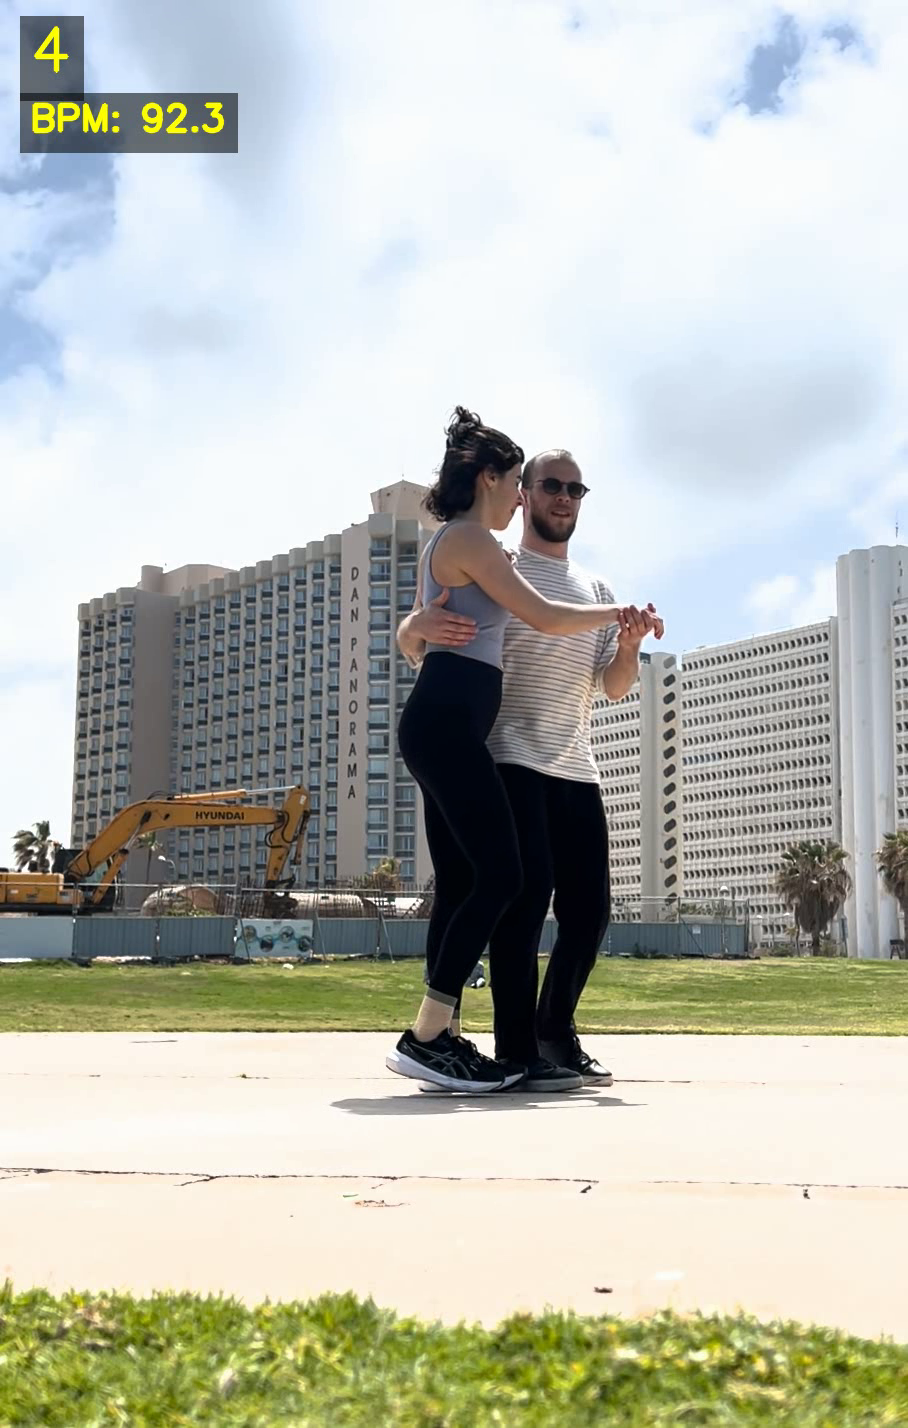

In [5]:
# (Optional) Show a sample frame from the output video at ~3s
from run import show_sample_frame
show_sample_frame(result, at_second=3.0)